In [3]:
############################ Data Analysis & Calculation ############################

import numpy as np 
import pandas as pd 

############################ Ignore Warning  ############################
import warnings
warnings.filterwarnings("ignore")

############################ Data visualization ############################

import seaborn as sns
import matplotlib.pyplot as plt


# 1. Data Importing

In [6]:
crop = pd.read_csv (r"C:\Users\HP\OneDrive\文档\Capstone 2 project\crop recomendation\Crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# 2. Data Pre-Processing 

1. Data Type and conversion
2. Data Manipulation

# 2.1. Data Type and conversion

In [10]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [12]:
crop.rainfall.value_counts()

rainfall
202.935536    1
26.036577     1
20.390205     1
21.179248     1
21.000099     1
             ..
65.816559     1
63.497263     1
65.628595     1
61.192509     1
140.937041    1
Name: count, Length: 2200, dtype: int64

# 3. Missing Value Identify & Treatment

In [15]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

# 4.Outlier identify 

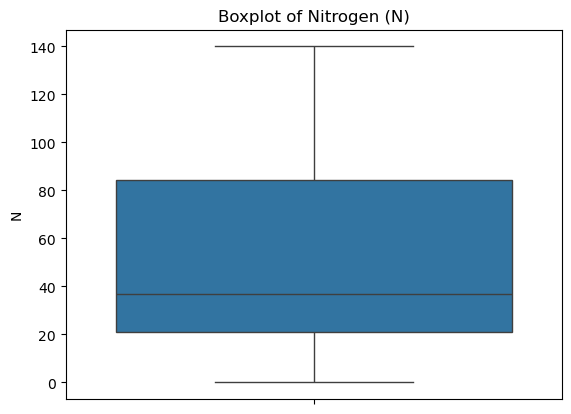

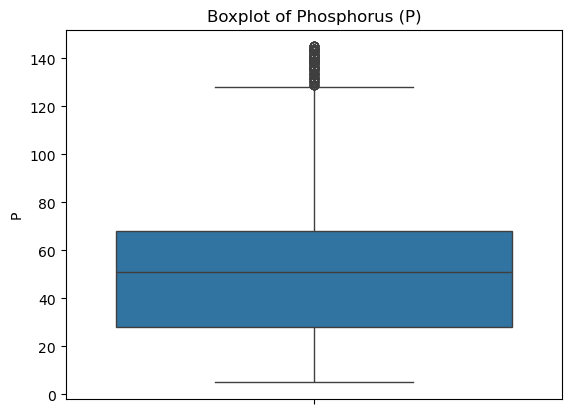

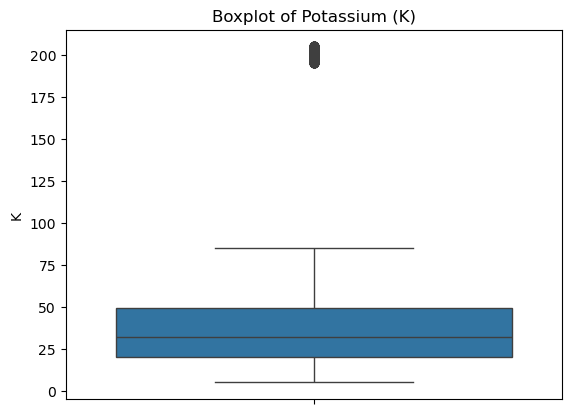

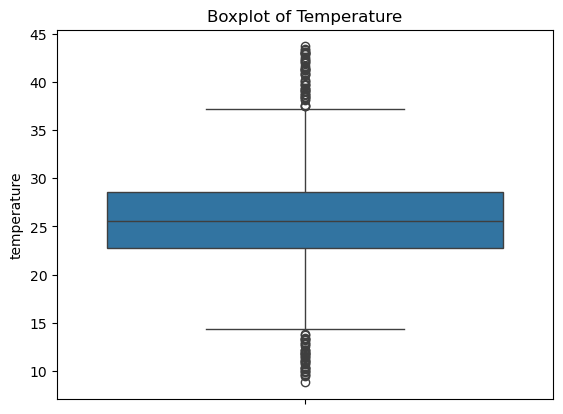

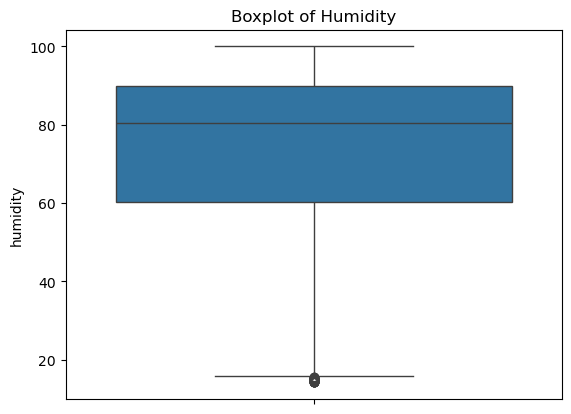

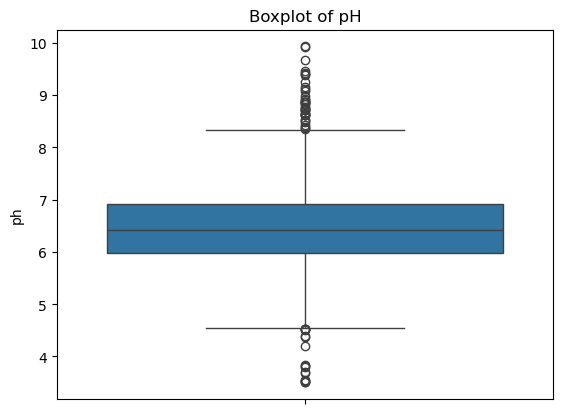

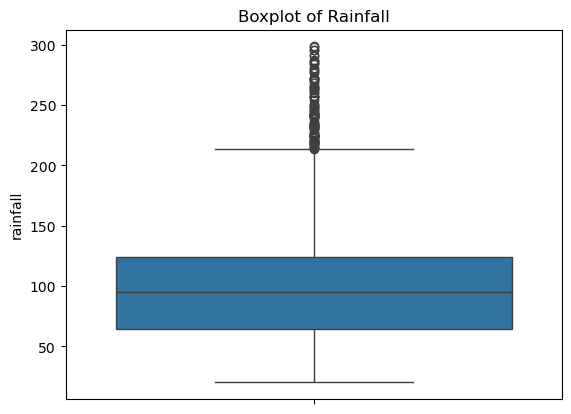

In [18]:

# Box plot for each numerical column
sns.boxplot(y=crop.N)
plt.title("Boxplot of Nitrogen (N)")
plt.show()

sns.boxplot(y=crop.P)
plt.title("Boxplot of Phosphorus (P)")
plt.show()

sns.boxplot(y=crop.K)
plt.title("Boxplot of Potassium (K)")
plt.show()

sns.boxplot(y=crop.temperature)
plt.title("Boxplot of Temperature")
plt.show()

sns.boxplot(y=crop.humidity)
plt.title("Boxplot of Humidity")
plt.show()

sns.boxplot(y=crop.ph)
plt.title("Boxplot of pH")
plt.show()

sns.boxplot(y=crop.rainfall)
plt.title("Boxplot of Rainfall")
plt.show()

# "Data Distribution Analysis and Transformation Techniques"

In [20]:
X = crop.drop('label', axis=1)
y = crop['label']


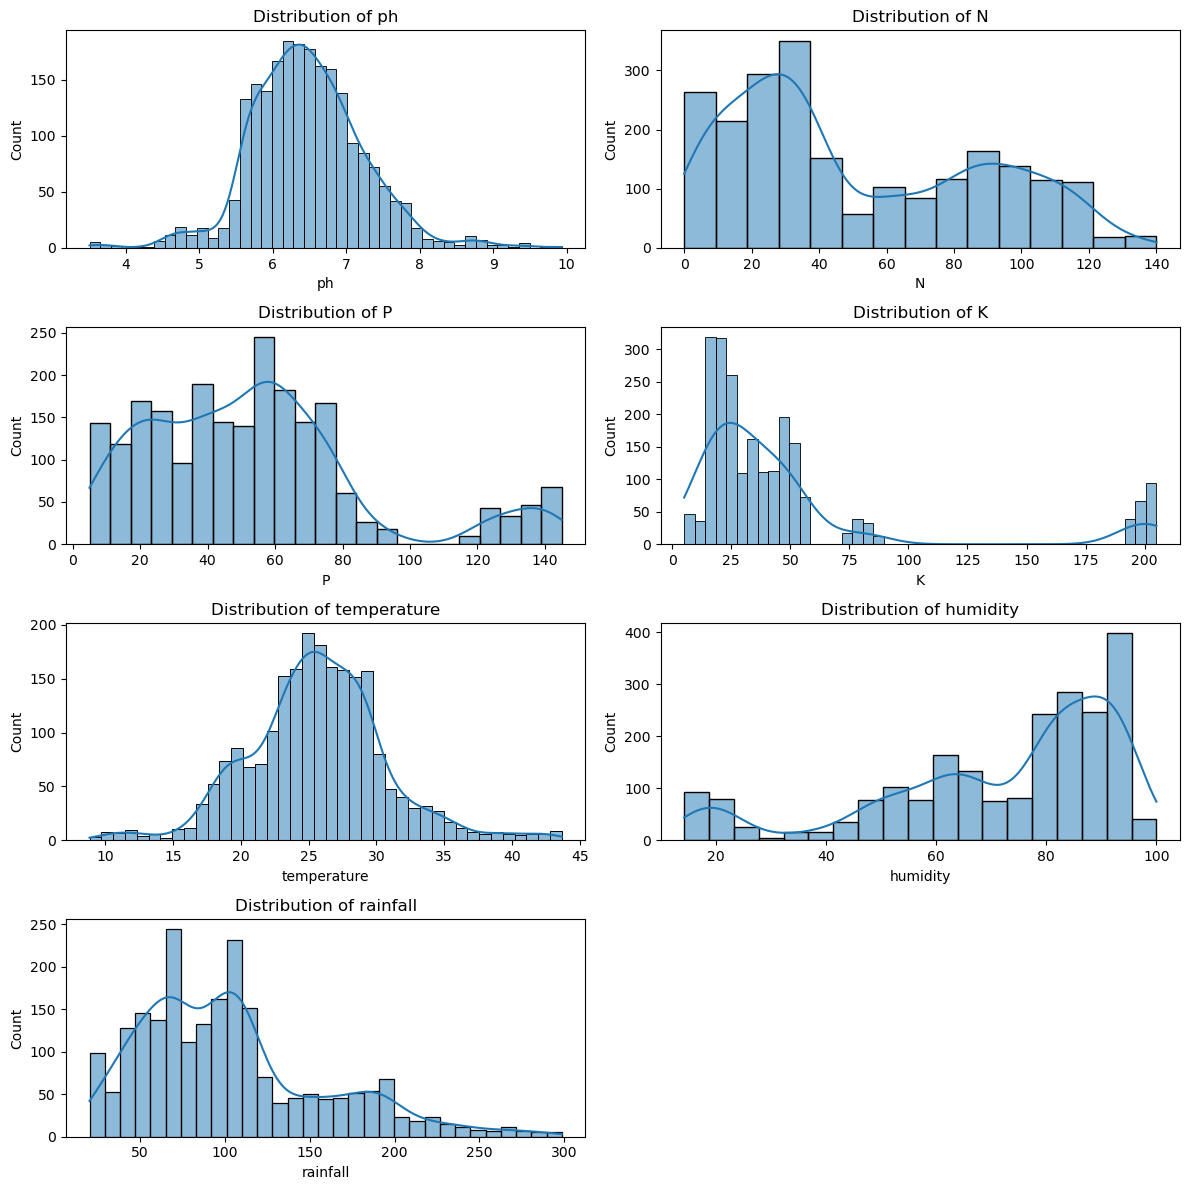

In [21]:
# Features to plot
features = ["ph", "N", "P", "K", "temperature", "humidity", "rainfall"]

# Create subplots (rows=4, cols=2 for 7 plots)
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

# Plot each feature
for i, col in enumerate(features):
    sns.histplot(crop[col], ax=axes[i], kde=True)
    axes[i].set_title(f"Distribution of {col}")

# Remove extra subplot (since we have 7 not 8)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()


# Data Partition

In [24]:
from sklearn.model_selection import train_test_split

X = crop.drop('label', axis = 1)
y = crop[['label']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1234)

In [26]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [27]:
y

,label
0,rice
1,rice
2,rice
3,rice
4,rice
...,...
2195,coffee
2196,coffee
2197,coffee
2198,coffee


# Label Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y['crop_label'] = le.fit_transform(y['label'])


In [30]:
y

,label,crop_label
0,rice,20
1,rice,20
2,rice,20
3,rice,20
4,rice,20
...,...,...
2195,coffee,5
2196,coffee,5
2197,coffee,5
2198,coffee,5


In [31]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       2200 non-null   object
 1   crop_label  2200 non-null   int32 
dtypes: int32(1), object(1)
memory usage: 25.9+ KB


# Model -- Random Forest 

In [33]:
from sklearn.ensemble import RandomForestRegressor  # y = Number
from sklearn.ensemble import RandomForestClassifier # y = Category

# by default 100 tree will be form 
RFModel = RandomForestClassifier(random_state=20,
                               n_estimators=25, # make 25 tress
                               criterion="gini",
                               max_depth=4,  # each tree will have 4 branches
                               min_samples_split=100,# each tree will have parent node
                               min_samples_leaf=50,# each tree will have Child node
                               max_features="sqrt")# Variable selection in each tree  

RFModel.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=50, min_samples_split=100,
                       n_estimators=25, random_state=20)

# Important Features

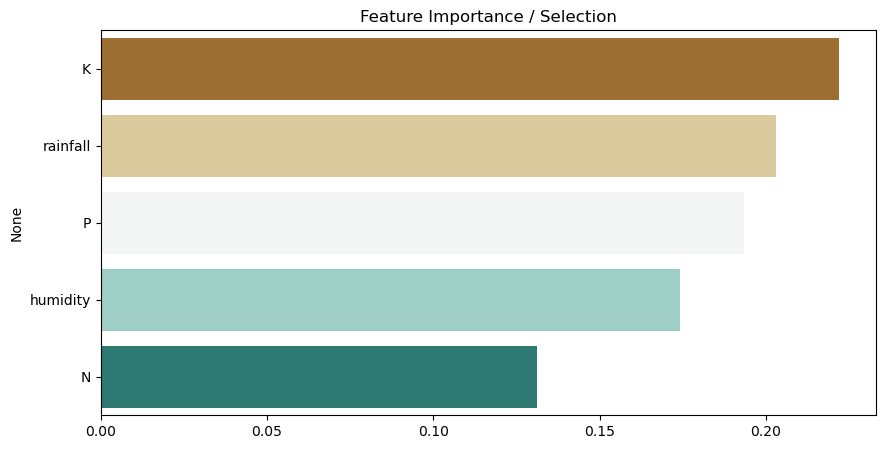

In [42]:
imp = pd.Series(data=RFModel.feature_importances_, index=RFModel.feature_names_in_).sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.title("Feature Importance / Selection")
ax = sns.barplot(y=imp.head().index, x=imp.head().values, palette="BrBG")

# Top 5 Variable are
* Potassium(K)
* rainfall
* Phosphorus(P)
* humidity
* Nitrogen(N)

# Random Forest Visualization

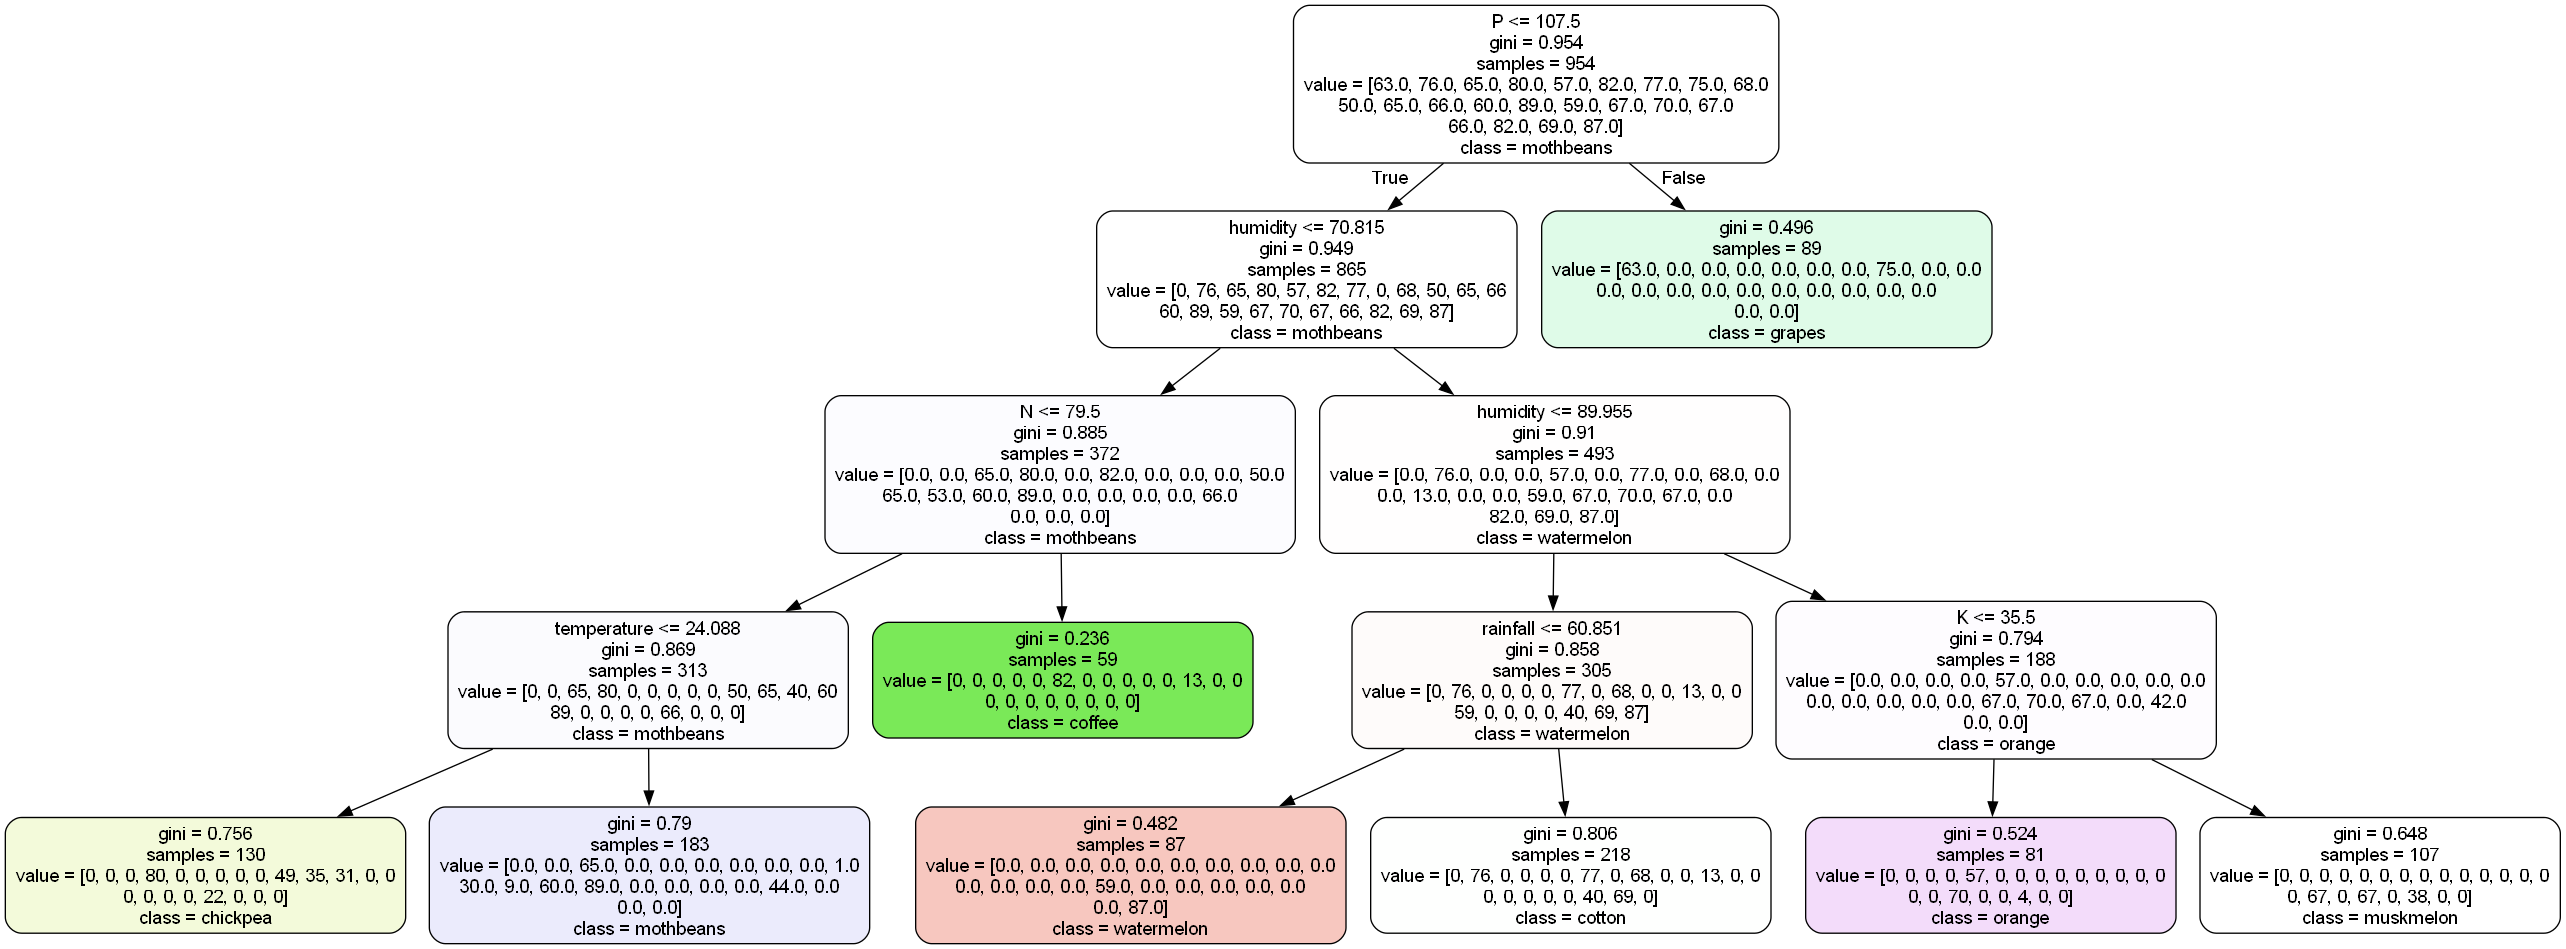

In [47]:
from sklearn.tree import export_graphviz
import pydot

tree = RFModel.estimators_[10]  # 0-24 specify the tree number   

export_graphviz(tree, out_file = 'abc.dot', 
                feature_names = list(X.columns),  # all independent variable name
                class_names = [str(c) for c in RFModel.classes_],
                rounded = True, 
                filled=True)
(graph, ) = pydot.graph_from_dot_file('abc.dot')
graph.write_png('tree.png')


from IPython.display import Image
Image(filename = 'tree.png')

# Predictions on Train Dataset

In [100]:
train = pd.concat([X_train,y_train],axis=1)
train.head()

,N,P,K,temperature,humidity,ph,rainfall,label
351,3,67,24,17.000676,19.907905,5.520880,103.292641,kidneybeans
58,71,46,40,20.280194,82.123542,7.236705,191.953574,rice
1096,92,81,52,28.010680,76.528081,5.891414,103.704078,banana
2133,82,24,33,26.535432,67.096081,6.809594,120.649443,coffee
1372,90,14,52,24.847408,89.204546,6.391858,59.679272,watermelon


In [101]:
train['Predicted'] = RFModel.predict(X_train)
train.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Predicted
351,3,67,24,17.000676,19.907905,5.520880,103.292641,kidneybeans,kidneybeans
58,71,46,40,20.280194,82.123542,7.236705,191.953574,rice,rice
1096,92,81,52,28.010680,76.528081,5.891414,103.704078,banana,banana
2133,82,24,33,26.535432,67.096081,6.809594,120.649443,coffee,coffee
1372,90,14,52,24.847408,89.204546,6.391858,59.679272,watermelon,watermelon


# Model Performance Metrics

In [102]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(train['Predicted'],train['label'])
print(confusion_matrix)

[[68  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 73  0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  1  0  0  2  0]
 [ 0  0 69  0  0  0  0  0  0  0  0  0  1 16  0  0  0  0  0  0  0  0]
 [ 0  0  0 68  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 69  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 70  0  0  2  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 69  0  0  0  0  2  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 78  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 60  0  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 66  0  0  7  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 65  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 67  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  2  0  0 48  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [103]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(train['label'], train['Predicted'])
print("Train Accuracy:", round(train_accuracy * 100,2), "%")


Train Accuracy: 94.03 %


In [104]:
from sklearn.metrics import classification_report
print(classification_report(train['label'], train['Predicted']))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        68
      banana       0.92      1.00      0.96        73
   blackgram       0.80      1.00      0.89        69
    chickpea       1.00      1.00      1.00        68
     coconut       1.00      0.97      0.99        71
      coffee       0.97      1.00      0.99        70
      cotton       0.97      1.00      0.99        69
      grapes       1.00      1.00      1.00        78
        jute       1.00      0.16      0.28        68
 kidneybeans       0.98      1.00      0.99        60
      lentil       0.90      0.97      0.94        68
       maize       1.00      0.97      0.98        67
       mango       1.00      0.99      0.99        68
   mothbeans       0.96      0.68      0.79        71
    mungbean       1.00      1.00      1.00        71
   muskmelon       0.99      1.00      0.99        73
      orange       0.97      1.00      0.99        67
      papaya       1.00    

# Predictions on Test Dataset

In [105]:
test = pd.concat([X_test,y_test],axis=1)
test.head()

,N,P,K,temperature,humidity,ph,rainfall,label
1835,29,25,35,28.357507,91.645093,5.542874,160.730699,coconut
1821,24,6,32,28.113215,90.017345,6.387068,172.481364,coconut
1934,131,52,16,23.657241,84.476015,6.486068,88.544791,cotton
1622,8,7,10,28.262049,91.983174,6.929216,105.213226,orange
789,60,59,22,31.868473,66.742175,7.191523,74.222386,blackgram


In [106]:
test['Predicted'] = RFModel.predict(X_test)
test.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Predicted
1835,29,25,35,28.357507,91.645093,5.542874,160.730699,coconut,coconut
1821,24,6,32,28.113215,90.017345,6.387068,172.481364,coconut,coconut
1934,131,52,16,23.657241,84.476015,6.486068,88.544791,cotton,cotton
1622,8,7,10,28.262049,91.983174,6.929216,105.213226,orange,orange
789,60,59,22,31.868473,66.742175,7.191523,74.222386,blackgram,maize


# Model Performance Metrics on Test data

In [107]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(test['Predicted'],test['label'])
print(confusion_matrix)

[[32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0 30  0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0]
 [ 0  0  0 32  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 30  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 31  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 40  0  0  0  0  0  0  0  0  2  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 28  0  0  3  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  0 32  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 31  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  4  0  0 19  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0

In [133]:
y_pred_test = RFModel.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred_test)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Accuracy: 92.42 %


In [134]:
from sklearn.metrics import classification_report
print(classification_report(test['label'], test['Predicted']))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        32
      banana       0.93      1.00      0.96        27
   blackgram       0.81      0.97      0.88        31
    chickpea       1.00      1.00      1.00        32
     coconut       1.00      0.93      0.96        29
      coffee       1.00      1.00      1.00        30
      cotton       0.97      1.00      0.98        31
      grapes       1.00      1.00      1.00        22
        jute       1.00      0.16      0.27        32
 kidneybeans       0.95      1.00      0.98        40
      lentil       0.90      0.88      0.89        32
       maize       0.97      0.97      0.97        33
       mango       1.00      0.97      0.98        32
   mothbeans       0.83      0.66      0.73        29
    mungbean       1.00      1.00      1.00        29
   muskmelon       1.00      1.00      1.00        27
      orange       0.94      1.00      0.97        33
      papaya       0.94    

# Finish

# Grid Search Method for Hyperparameter Tuning
#### -- It givees us more Optmized random Forest Model

In [162]:
## Before Tuning Test Accuracy
print("Before Tuning Test Accuracy:", accuracy_score(y_test, y_pred_test))

Before Tuning Test Accuracy: 0.9242424242424242


In [142]:
params = {
    'n_estimators': [100, 150], # no. of trees
    'max_depth': [5, 10], # Branches
    'min_samples_split': [2, 5], # Parent
    'min_samples_leaf': [1, 2] # Child
}

In [143]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

grid_search_cv = GridSearchCV(RandomForestClassifier(random_state=42),
                              params, 
                              verbose=1, 
                              cv=5)
grid_search_cv.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 150]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [115]:
grid_search_cv.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,100
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [163]:
## Test Accuracy after tuning
from sklearn.metrics import accuracy_score
print("Test Accuracy after tuning:", accuracy_score(y_test, y_pred))

Test Accuracy after tuning: 0.9954545454545455


In [148]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        32
      banana       1.00      1.00      1.00        27
   blackgram       1.00      0.97      0.98        31
    chickpea       1.00      1.00      1.00        32
     coconut       1.00      1.00      1.00        29
      coffee       1.00      1.00      1.00        30
      cotton       1.00      1.00      1.00        31
      grapes       1.00      1.00      1.00        22
        jute       0.94      1.00      0.97        32
 kidneybeans       1.00      1.00      1.00        40
      lentil       1.00      1.00      1.00        32
       maize       0.97      1.00      0.99        33
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      1.00      1.00        29
    mungbean       1.00      1.00      1.00        29
   muskmelon       1.00      1.00      1.00        27
      orange       1.00      1.00      1.00        33
      papaya       1.00    

#### Model Export  -- Python to Laptop

In [173]:
import os
print(os.getcwd())

C:\Users\HP\OneDrive\文档\Capstone 2 project


In [174]:
import pickle

with open('rf_model.pkl', 'wb') as f:
    pickle.dump(RFModel, f)